In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [56]:
df=pd.read_csv('https://raw.githubusercontent.com/juliandnl/redi_ss20/master/cars.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Make      10000 non-null  object 
 1   Model     10000 non-null  object 
 2   Year      10000 non-null  int64  
 3   Variant   10000 non-null  object 
 4   Kms       10000 non-null  int64  
 5   Price     10000 non-null  int64  
 6   Doors     10000 non-null  float64
 7   Kind      10000 non-null  object 
 8   Location  10000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB


In [9]:
df.head()

,Make,Model,Year,Variant,Kms,Price,Doors,Kind,Location
0,Volkswagen,Vento,2012,2.5 Luxury 170cv,99950,360000,4.0,Sedán,Córdoba
1,Ford,Ranger,2012,2.3 Cd Xl Plus 4x2,140000,320000,2.0,Pick-Up,Entre Ríos
2,Volkswagen,Fox,2011,1.6 Trendline,132000,209980,5.0,Hatchback,Bs.as. G.b.a. Sur
3,Ford,Ranger,2017,3.2 Cd Xls Tdci 200cv Automática,13000,798000,4.0,Pick-Up,Neuquén
4,Volkswagen,Gol,2013,1.4 Power 83cv 3 p,107000,146000,3.0,Hatchback,Córdoba


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Kms'}>],
       [<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Doors'}>]], dtype=object)

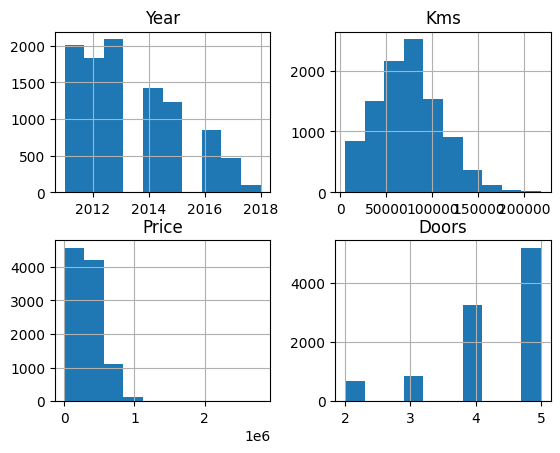

In [10]:
df.hist()

In [18]:
X=df[['Year','Kms']]
X

,Year,Kms
0,2012,99950
1,2012,140000
2,2011,132000
3,2017,13000
4,2013,107000
...,...,...
9995,2016,67000
9996,2012,120000
9997,2012,89000
9998,2013,76000


In [19]:
Y=df['Price']
Y

,Price
0,360000
1,320000
2,209980
3,798000
4,146000
...,...
9995,399000
9996,240000
9997,250000
9998,295000


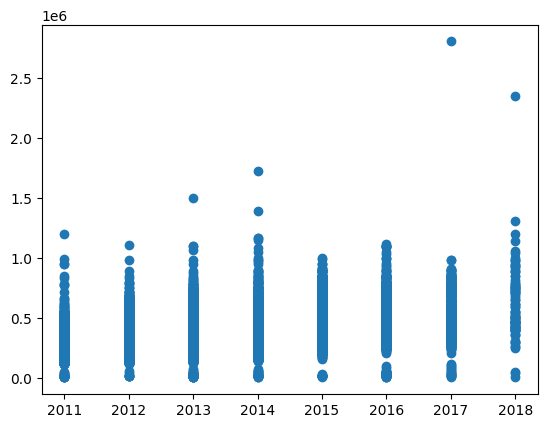

In [16]:
plt.scatter(X['Year'],Y)

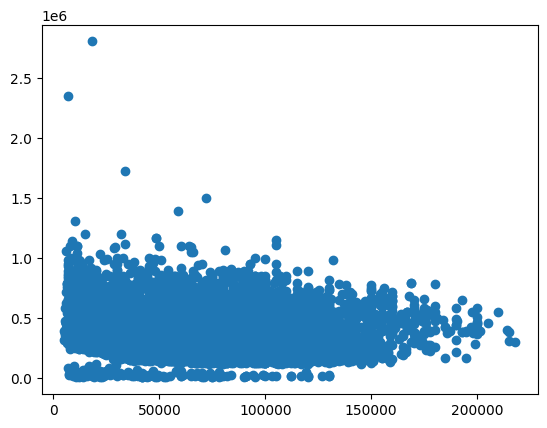

In [20]:
plt.scatter(X['Kms'],Y)

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [24]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(X_train,Y_train)

LinearRegression()

In [25]:
regr.coef_

array([6.26071136e+04, 1.42009798e+00])

In [26]:
X_train.head()

,Year,Kms
9254,2011,110000
1561,2012,39000
1670,2011,117000
6087,2014,43000
6669,2014,93000


In [32]:
Y_pred=regr.predict(X_test)
Y_pred

array([456356.26887719, 295271.1843344 , 423571.21277861, ...,
       382265.56882983, 350900.6107063 , 339417.02423324])

In [37]:
from sklearn.metrics import mean_squared_error
RMSE=np.sqrt(mean_squared_error(Y_test,Y_pred))
RMSE

np.float64(148873.566832348)

In [42]:
X_sort = X.sort_values(by='Year')
X_sort

,Year,Kms
25,2011,79800
20,2011,85000
2037,2011,136000
2036,2011,103000
2034,2011,145152
...,...,...
4006,2018,8000
2079,2018,6500
8112,2018,7600
6054,2018,17000


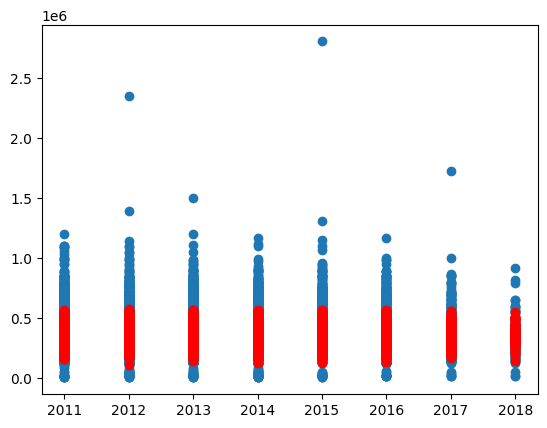

In [45]:
plt.scatter(X_sort['Year'],Y)
plt.scatter(X_sort['Year'],regr.predict(X),color='red')

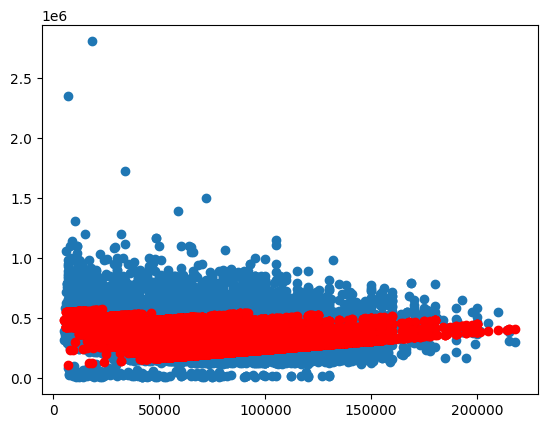

In [54]:
plt.scatter(X['Kms'],Y),
plt.scatter(X['Kms'],
regr.predict(X),color='red')

In [57]:
df[['Year','Kms','Price']].groupby(['Year']).mean()

,Kms,Price
Year,,
2011,103171.582008,259129.435388
2012,90865.334242,285969.183206
2013,79694.472954,333559.201532
2014,67341.004234,369082.293578
2015,54049.414911,433691.940032
2016,37969.374852,472929.067616
2017,18774.124736,496487.359408
2018,11386.316327,623778.346939
